In [2]:
import seaborn
import matplotlib.pyplot as plt
import numpy as np
import scipy
import random
import statistics
import math

from enum import StrEnum

from time import perf_counter

# Exercise 1

In [3]:
NUM_SAMPLES = 10_000

def LCG_sample(x:int, a: int, c: int, M: int):
    return int((a*x + c) % M)

def sample_numbers(num: int = NUM_SAMPLES, a: int = 23, c: int = 1, M: int = 1e8 + 1, seed: int = 5_000, uniform: bool = True) -> list[int] | list[float]:
    samples = [seed/M if uniform else seed]
    x = seed
    for _ in range(num):
        x = LCG_sample(x, a, c, M)
        samples.append(x/M if uniform else x)
    return samples

def cycle_length(samples: list[int] | list[float]) -> int:
    first = samples[0]
    try:
        repeated_first = samples[1:].index(first)
    except ValueError:
        return len(samples)
    return repeated_first + 1

def plot_samples(samples: list[int] | list[float], save_fig: bool = False, filename: str = "lcg_samples.png"):
    # left = histogram, right = scatterplot of i vs i+1
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    seaborn.histplot(samples, bins=10, ax=ax1)
    ax1.set_title("Histogram of samples")
    ax1.set_xlabel("Value")
    ax1.set_ylabel("Frequency")

    # Scatter with small dots
    ax2.scatter(samples[:-1], samples[1:], alpha=0.5, s=10)
    ax2.set_title("Scatterplot of i vs i+1")
    ax2.set_xlabel("Sample i")
    ax2.set_ylabel("Sample i+1")

    # Big title
    plt.suptitle(f"LCG Samples (Cycle of length {cycle_length(samples)})", fontsize=16)
    if save_fig:
        plt.savefig(filename)
    plt.show()


def chi_square_test(samples: list[int] | list[float], num_bins: int = 10, range: tuple[float, float] = (0, 1)) -> float:
    # First we get the test statistic based on the observed counts versus the expected number.
    # Expected is the same for each bin, as we want to assume an underlying uniform distribution.
    observed_counts, _ = np.histogram(samples, bins=num_bins, range=range)
    expected_count = len(samples) / num_bins
    chi_square_statistic = np.sum((observed_counts - expected_count) ** 2 / expected_count)
    
    # Uniform has no parameters to estiamte, so df = num_bins - 1
    degrees_of_freedom = num_bins - 1

    # We can get the p-value from the chi-square distribution scipy.
    p_value = scipy.stats.chi2.sf(chi_square_statistic, df=degrees_of_freedom)
    return p_value

def wald_wolfowitz_test(samples: list[int] | list[float]) -> float:
    median = statistics.median(samples)
    n_pos = sum(1 for x in samples if x > median)
    n_neg = sum(1 for x in samples if x < median)

    sides = [1 if value > median else -1 for value in samples if value != median]

    total_runs = 1
    for previous_side, current_side in zip(sides, sides[1:]):
        if current_side != previous_side:
            total_runs += 1

    expected_runs = (2 * n_pos * n_neg) / (n_pos + n_neg) + 1
    variance_runs = (2 * n_pos * n_neg * (2 * n_pos * n_neg - n_pos - n_neg)) \
                    / ((n_pos + n_neg) ** 2 * (n_pos + n_neg - 1))

    z_score = (total_runs - expected_runs) / np.sqrt(variance_runs)
    p_value = 2 * scipy.stats.norm.sf(abs(z_score))
    
    return p_value

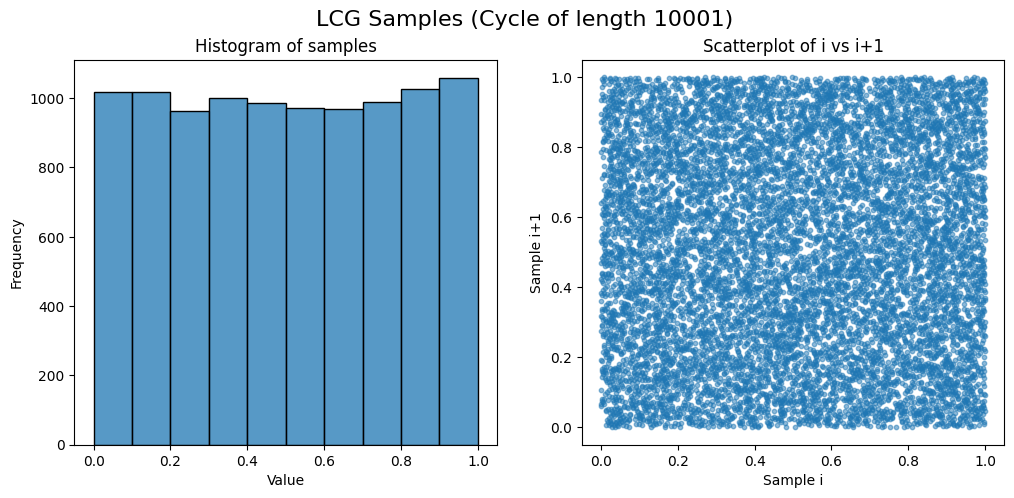

0.5109384006486712
0.6030454504339671


In [4]:
a_ = 6969
c_ = 67
M_ = 2**15

# C-style LCG parameters.
C_sample_numbers = sample_numbers(a=a_, c=c_, M=M_, uniform=True)
plot_samples(C_sample_numbers)
print(chi_square_test(C_sample_numbers))
print(wald_wolfowitz_test(C_sample_numbers))

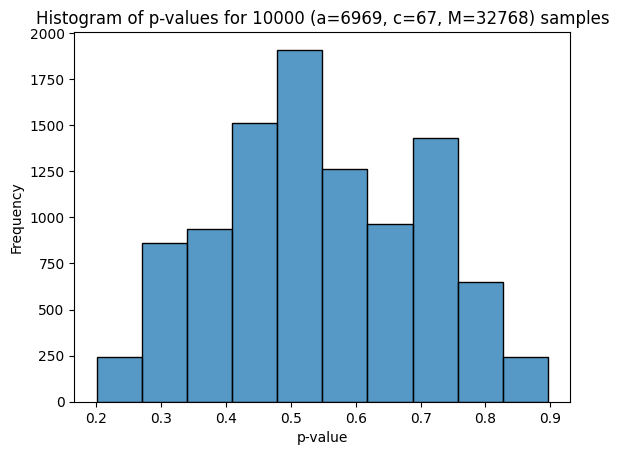

In [5]:
# Check uniformity of P-values for 'C_sample_numbers' setup.
p_values = []
for _ in range(10000):
    samples = sample_numbers(a=a_, c=c_, M=M_, uniform=True, seed=random.randint(0, int(1e8)))
    p_values.append(chi_square_test(samples))
seaborn.histplot(p_values, bins=10)
plt.title(f"Histogram of p-values for 10000 (a={a_}, c={c_}, M={M_}) samples")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

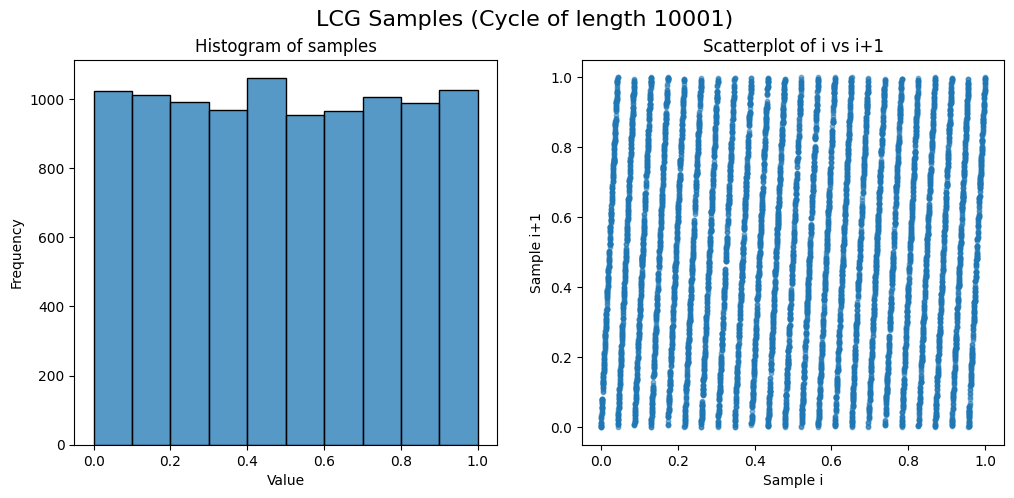

0.3922864084396708


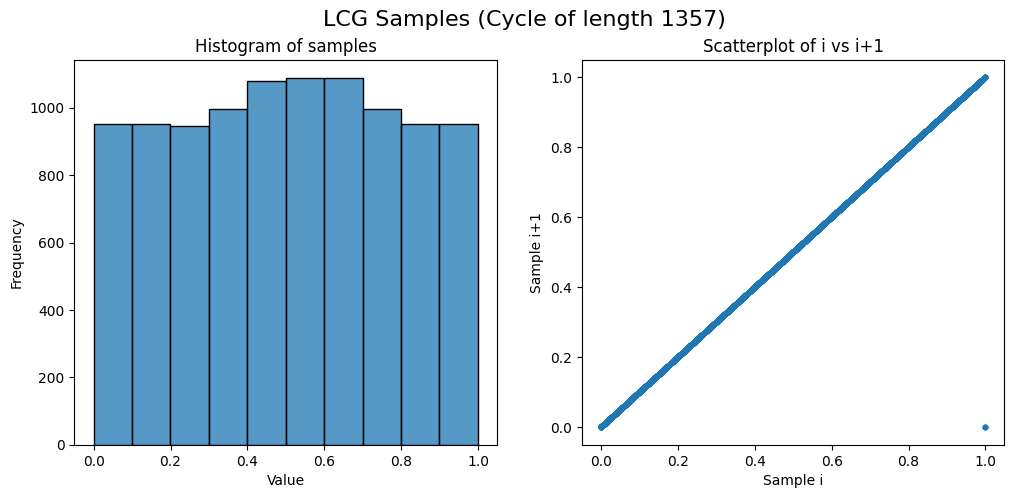

7.959351269325636e-05


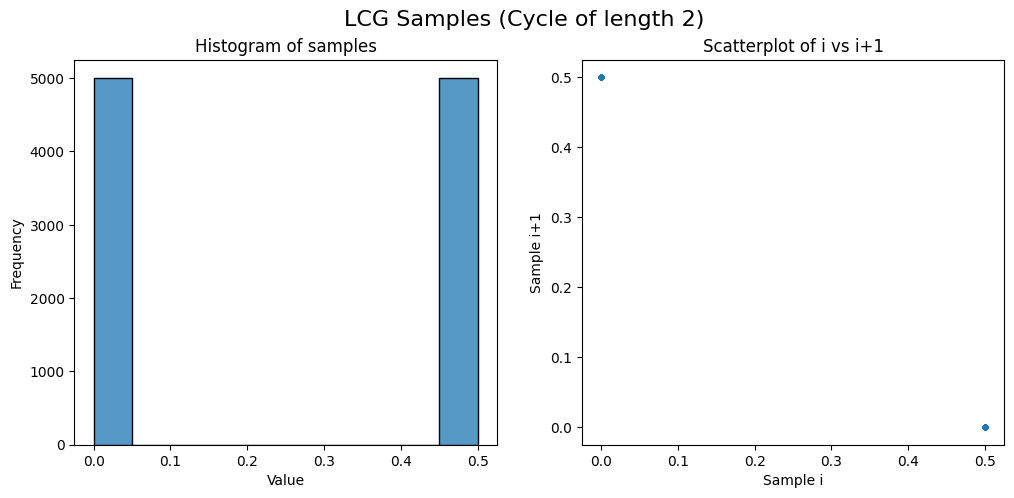

0.0
nan


/tmp/ipykernel_5530/3018725792.py:73: RuntimeWarning: invalid value encountered in scalar divide
  z_score = (total_runs - expected_runs) / np.sqrt(variance_runs)


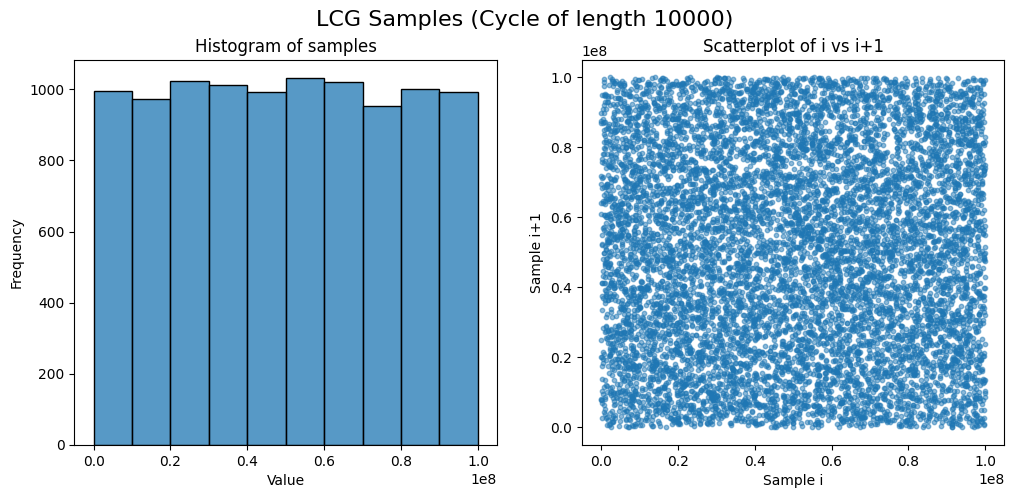

0.0


In [6]:
example_sample_numbers = sample_numbers(a=23, c=1, M=1e8+1, uniform=True, seed=500) # with numbers from lecture
plot_samples(example_sample_numbers)
print(chi_square_test(example_sample_numbers))

bad_sample_numbers = sample_numbers(a=1358, M=23*59, uniform=True, seed=500)  # has max cycle length
plot_samples(bad_sample_numbers)
print(chi_square_test(bad_sample_numbers))

really_bad = sample_numbers(a = 1, c=32, M = 64, uniform=True, seed=0)
plot_samples(really_bad)
print(chi_square_test(really_bad))
print(wald_wolfowitz_test(really_bad))

built_in_numbers = [random.randint(0, int(1e8)) for _ in range(10_000)]
plot_samples(built_in_numbers)
print(chi_square_test(built_in_numbers))

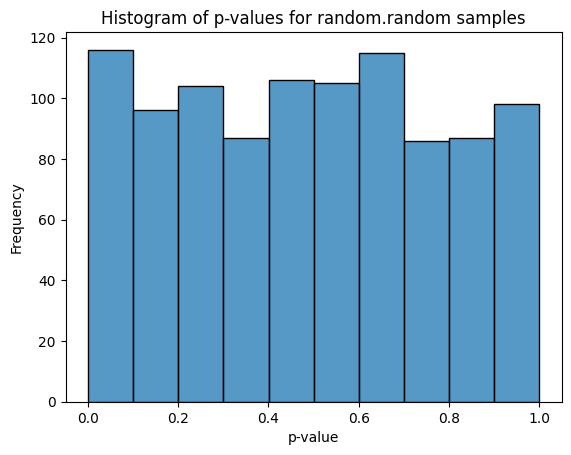

In [7]:
# Check uniformity of P-values for 'C_sample_numbers' setup.
p_values = []
for _ in range(1000):
    samples = [random.random() for _ in range(10_000)]
    p_values.append(chi_square_test(samples))
seaborn.histplot(p_values, bins=10)
plt.title("Histogram of p-values for random.random samples")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.show()

# Exercise 2

0.1: Theo Mean: 10.00  | Sample Mean: 9.93   | Theo Var: 90.00   | Sample Var: 90.85 
0.2: Theo Mean: 5.00   | Sample Mean: 5.00   | Theo Var: 20.00   | Sample Var: 20.67 
0.3: Theo Mean: 3.33   | Sample Mean: 3.30   | Theo Var: 7.78    | Sample Var: 7.43  
0.4: Theo Mean: 2.50   | Sample Mean: 2.51   | Theo Var: 3.75    | Sample Var: 3.81  
0.5: Theo Mean: 2.00   | Sample Mean: 2.00   | Theo Var: 2.00    | Sample Var: 2.04  
0.6: Theo Mean: 1.67   | Sample Mean: 1.66   | Theo Var: 1.11    | Sample Var: 1.12  
0.7: Theo Mean: 1.43   | Sample Mean: 1.43   | Theo Var: 0.61    | Sample Var: 0.63  
0.8: Theo Mean: 1.25   | Sample Mean: 1.24   | Theo Var: 0.31    | Sample Var: 0.30  
0.9: Theo Mean: 1.11   | Sample Mean: 1.11   | Theo Var: 0.12    | Sample Var: 0.13  


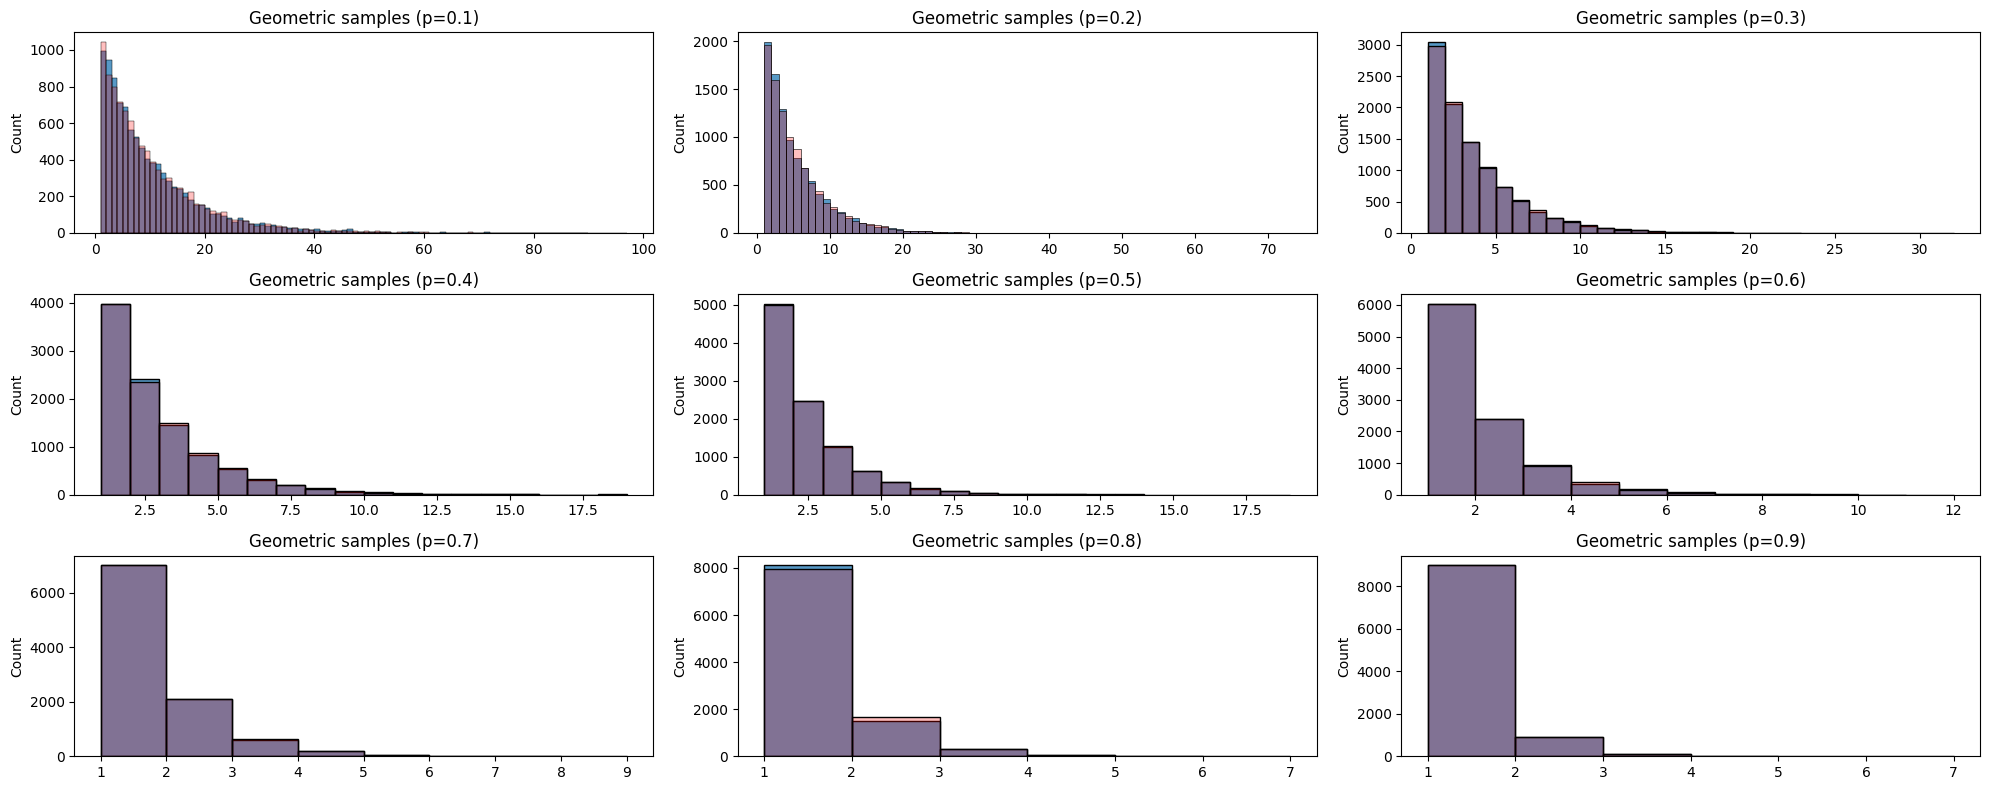

In [8]:
NUM_OUTCOMES = 10_000
P = 0.5

samples_geometric = lambda n, p: [math.floor(math.log(random.random())/math.log(1 - p)) + 1 for _ in range(n)]

# PLT figure with 10 subplots, each with a histogram of geometric samples for p in [0.1, 0.2, ..., 0.9]

fig, axes = plt.subplots(3, 3, figsize=(20, 8))
for p__ in range(1, 10):
    p_ = p__ / 10
    samples = samples_geometric(NUM_OUTCOMES, p_)
    samples_builtin = scipy.stats.geom.rvs(p_, size=NUM_OUTCOMES)  # Built-in geometric samples for comparison
    ax = axes[(p__ - 1) // 3, (p__ - 1) % 3]

    # Theoretical mean and var
    mean = 1 / (p_)
    var = (1 - p_) / (p_) ** 2

    # Sample mean and var
    sample_mean = statistics.mean(samples)
    sample_var = statistics.variance(samples, sample_mean)

    print(f"{p_:.1f}: "
      f"Theo Mean: {mean:<6.2f} | Sample Mean: {sample_mean:<6.2f} | "
      f"Theo Var: {var:<6.2f}  | Sample Var: {sample_var:<6.2f}")

    # Chi square test for fit most like the way to go

    seaborn.histplot(samples, bins=range(1, max(samples)+1), ax=ax)
    seaborn.histplot(samples_builtin, bins=range(1, max(samples_builtin)+1), ax=ax, color='red', alpha=0.25)
    ax.set_title(f"Geometric samples (p={p_:.1f})")
fig.tight_layout()

Direct method took 0.0767 seconds
Rejection sampling took 0.0856 seconds
Alias method took 0.0063 seconds, table generations took 0.0001 seconds


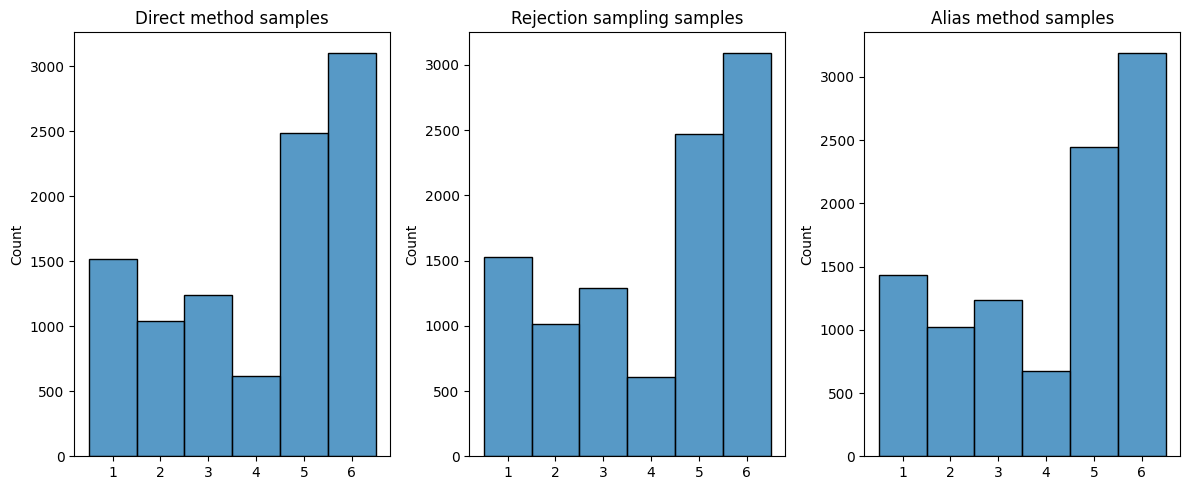

In [9]:
# Part 2 of the exercise
NUM_CLASSES = 6
class_probs = [7/48, 5/48, 1/8, 1/16, 1/4, 5/16]

# Alias method requires a larger amount of memory, because we need to build the alias tables.
# It is also a bit more complex to implement, and intuitively get, than the direct (crude) method and the rejection sampling.
# However, it works very fast once the pre-processing is done, as will be seen by the timings.
def generate_alias_tables(probs: list[float]) -> tuple[list[int], list[float]]:
    k = len(probs)
    scaled_probs = [p * k for p in probs]
    
    L = [0] * k
    F = [0.0] * k
    
    S = []
    G = []

    
    for i, sp in enumerate(scaled_probs):
        if sp < 1:
            S.append(i)
        else:
            G.append(i)

    while S and G:
        s = S.pop()
        g = G.pop()

        F[s] = scaled_probs[s]
        L[s] = g

        scaled_probs[g] = scaled_probs[g] - (1 - scaled_probs[s])
        if scaled_probs[g] < 1:
            S.append(g)
        else:
            G.append(g)

    for g in G:
        F[g] = 1
    for s in S:
        F[s] = 1

    return L, F

# Sampling with Alias is very fast, and this part is simple to understand.
def alias_method_sample(alias: list[int], prob: list[float]) -> int:
    n = len(alias)
    i = random.randint(0, n - 1)  # first sample class randomly uniformly
    r = random.random()           # Here we decide whether to use the 'alias'
    if r < prob[i]:
        return i + 1
    else:
        return alias[i] + 1

# Intuitive, simple, but not neccesarily fast.
def direct_method_sample(class_probs: list[float]) -> int:
    cumulative_probs = np.cumsum(class_probs)
    r = random.random()
    for i, cp in enumerate(cumulative_probs):
        if r < cp:
            return i + 1

# Simple, but can be very inefficient if the probabilities are very skewed.
def rejection_sample(c: float, proposal_probs: list[float] | None = None) -> int:

    # If we don't have proposal distribution, just assume equally likely classes.
    if proposal_probs is None:
        proposal_probs = [1/NUM_CLASSES] * NUM_CLASSES
    
    while True:
        [candidate] = random.choices(range(1, NUM_CLASSES + 1), weights=proposal_probs)
        r = random.random()
        if r < class_probs[candidate - 1] / c:
            return candidate

sample_direct_start = perf_counter()
samples_direct = [direct_method_sample(class_probs) for _ in range(NUM_OUTCOMES)]
sample_direct_end = perf_counter()

sample_rejection_start = perf_counter()
samples_rejection = [rejection_sample(1.0) for _ in range(NUM_OUTCOMES)]
sample_rejection_end = perf_counter()

alias_generate_start = perf_counter()
alias, probs = generate_alias_tables(class_probs)

sample_alias_start = perf_counter()
samples_alias = [alias_method_sample(alias, probs) for _ in range(NUM_OUTCOMES)]
sample_alias_end = perf_counter()

print(f"Direct method took {sample_direct_end - sample_direct_start:.4f} seconds")
print(f"Rejection sampling took {sample_rejection_end - sample_rejection_start:.4f} seconds")
print(f"Alias method took {sample_alias_end - sample_alias_start:.4f} seconds, table generations took {sample_alias_start - alias_generate_start:.4f} seconds")

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
seaborn.histplot(samples_direct, bins=np.arange(1, NUM_CLASSES + 2) - 0.5, ax=axes[0], discrete=True)
axes[0].set_title("Direct method samples")
seaborn.histplot(samples_rejection, bins=np.arange(1, NUM_CLASSES + 2) - 0.5, ax=axes[1], discrete=True)
axes[1].set_title("Rejection sampling samples")
seaborn.histplot(samples_alias, bins=np.arange(1, NUM_CLASSES + 2) - 0.5, ax=axes[2], discrete=True)
axes[2].set_title("Alias method samples")
fig.tight_layout()


In [10]:
# Disadvantage Rejection Sampling - wrong M
for i in [1.0, 10, 100]:
    sample_rejection_start = perf_counter()
    samples_rejection = [rejection_sample(i) for _ in range(NUM_OUTCOMES)]
    sample_rejection_end = perf_counter()
    print(f"Rejection sampling with c={i} took {sample_rejection_end - sample_rejection_start:.4f} seconds")

# Disadvantage Direct Method - many, many classes
class_probs_ = [1/1000] * 1_000
sample_direct_start = perf_counter()
samples_direct = [direct_method_sample(class_probs_) for _ in range(NUM_OUTCOMES)]
sample_direct_end = perf_counter()
print(f"Direct method with 1000 classes took {sample_direct_end - sample_direct_start:.4f} seconds")

Rejection sampling with c=1.0 took 0.1230 seconds
Rejection sampling with c=10 took 0.8127 seconds
Rejection sampling with c=100 took 7.5952 seconds
Direct method with 1000 classes took 0.8399 seconds


# Exercise 3

In [11]:
def sample_exponential_dist(lamb: float, num_samples: int = NUM_SAMPLES) -> list[float]:
    return [-math.log(random.random()) / lamb for _ in range(num_samples)]

def sample_standard_normal_box_mueller(num_samples:int = NUM_SAMPLES) -> list[float]:
    # From slides
    samples = []
    for _ in range(num_samples // 2):
        u1, u2 = random.random(), random.random()
        scale = math.sqrt(-2.0 * math.log(u1))
        z0 = scale * math.cos(2.0 * math.pi * u2)
        z1 = scale * math.sin(2.0 * math.pi * u2)
        samples.extend([z0, z1])
    if num_samples % 2 == 1:
        u1, u2 = random.random(), random.random()
        scale = math.sqrt(-2.0 * math.log(u1))
        z0 = scale * math.cos(2.0 * math.pi * u2)
        samples.append(z0)
    return samples

def sample_pareto(k: float, beta: float, non_negative: bool = False, num_samples: int = NUM_SAMPLES) -> list[float]:
    if not non_negative:
        return [beta*random.random() ** (-1 / k) for _ in range(num_samples)]
    return [beta*(random.random() ** (-1 / k) - 1) for _ in range(num_samples)]

def sample_pareto_composition(mu: float, num_samples: int = NUM_SAMPLES) -> list[float]:
    ys = sample_exponential_dist(mu, num_samples)
    samples = []
    for y in ys:
        [x] = sample_exponential_dist(y, num_samples=1)
        samples.append(x)
    return samples

def sample_erlang(lamb: float, n: int, num_samples: int = NUM_SAMPLES) -> list[float]:
    samples = []
    for _ in range(num_samples):
        total = 1
        for _ in range(n):
            total *= random.random() 
        samples.append(-1/lamb * math.log(total))
    return samples


def sample_hyperexponential(lambdas: list[float], ps: list[float], num_samples: int = NUM_SAMPLES) -> list[float]:
    samples = []
    for _ in range(num_samples):
        [i] = random.choices(range(len(lambdas)), weights=ps)
        samples.append(sample_exponential_dist(lambdas[i], num_samples=1)[0])
    return samples

KS test for exponential samples: statistic=0.0083, p-value=0.4942
KS test for normal samples: statistic=0.0075, p-value=0.6239


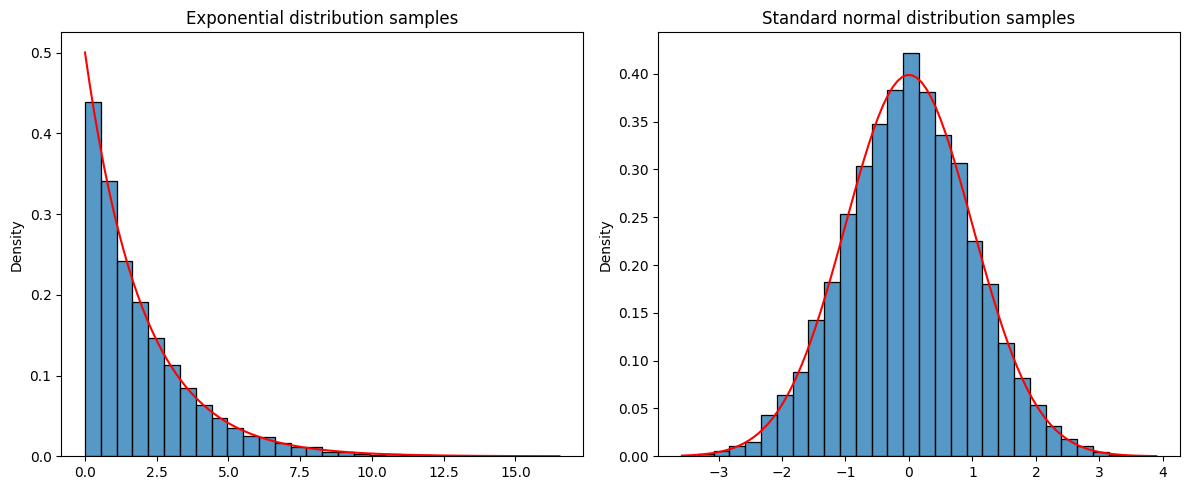

In [12]:

# Plot samples versus theoretical PDF for exponential distribution, normal distribution.
exp_samples = sample_exponential_dist(0.5)
normal_samples = sample_standard_normal_box_mueller()

# Also do Kolmogorov-Smirnov test for both samples to check if they fit the theoretical distribution.
ks_exp = scipy.stats.kstest(exp_samples, 'expon', args=(0, 1/0.5))
ks_normal = scipy.stats.kstest(normal_samples, 'norm')

print(f"KS test for exponential samples: statistic={ks_exp.statistic:.4f}, p-value={ks_exp.pvalue:.4f}")
print(f"KS test for normal samples: statistic={ks_normal.statistic:.4f}, p-value={ks_normal.pvalue:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
seaborn.histplot(exp_samples, bins=30, ax=axes[0], stat='density')
x_exp = np.linspace(0, max(exp_samples), 100)
axes[0].plot(x_exp, 0.5 * np.exp(-0.5 * x_exp), color='red')
axes[0].set_title("Exponential distribution samples")

seaborn.histplot(normal_samples, bins=30, ax=axes[1], stat='density')
x_norm = np.linspace(min(normal_samples), max(normal_samples), 100)
axes[1].plot(x_norm, (1/np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_norm**2), color='red')
axes[1].set_title("Standard normal distribution samples")
fig.tight_layout()


KS test for Pareto samples (k=2.05): statistic=0.0092, p-value=0.3575
KS test for Pareto samples (k=2.5): statistic=0.0063, p-value=0.8189
KS test for Pareto samples (k=3): statistic=0.0103, p-value=0.2330
KS test for Pareto samples (k=4): statistic=0.0088, p-value=0.4243


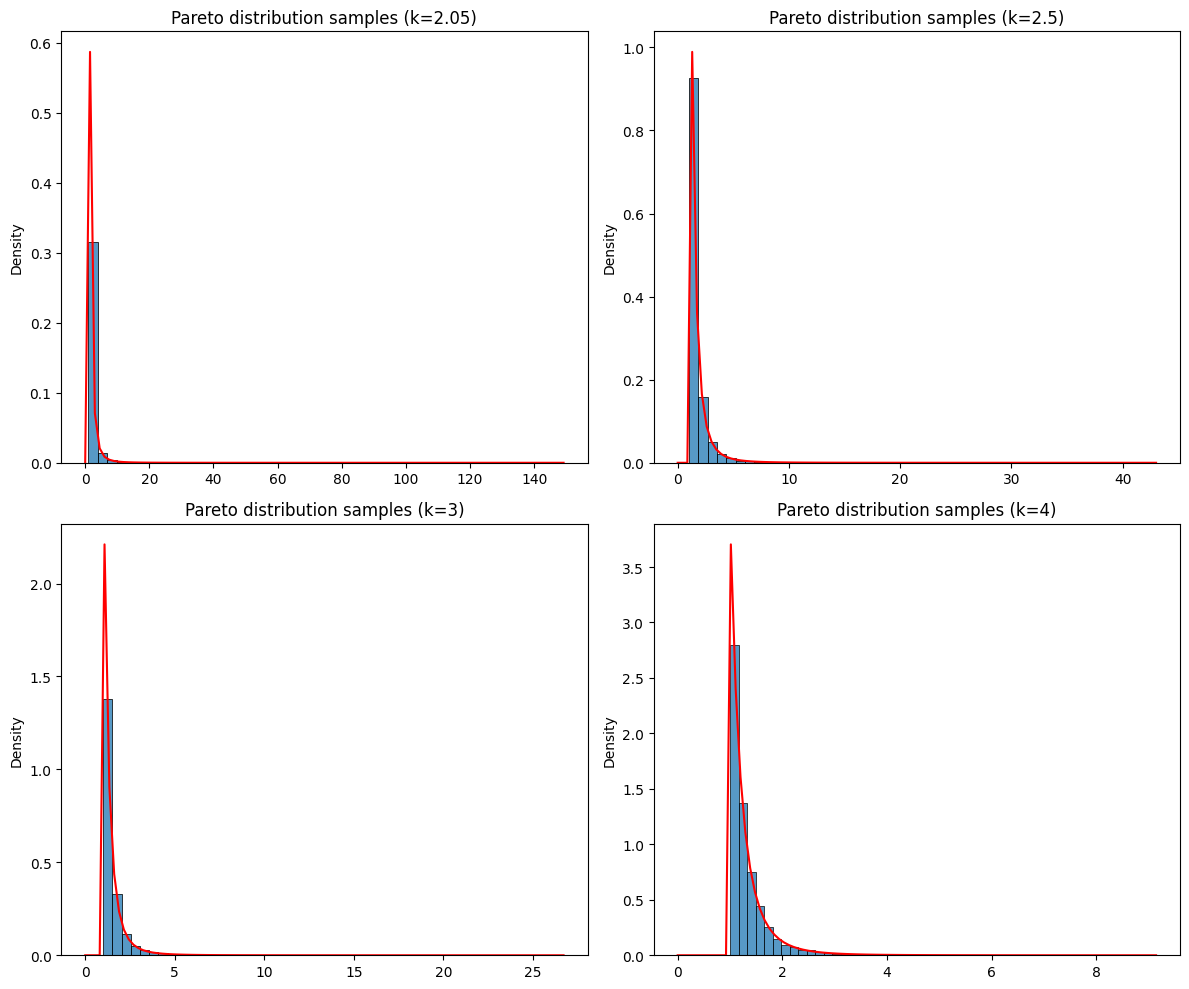

In [13]:
# Pareto distribution samples for k = 2.05, 2.5, 3, 4
BETA_ = 1
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, k in enumerate([2.05, 2.5, 3, 4]):
    samples = sample_pareto(k, BETA_)
    x_pareto = np.linspace(0, max(samples), 100)
    axes[i//2, i%2].plot(x_pareto, scipy.stats.pareto.pdf(x_pareto, k, scale=BETA_), color='red')
    seaborn.histplot(samples, bins=50, ax=axes[i//2, i%2], stat='density')
    axes[i//2, i%2].set_title(f"Pareto distribution samples (k={k})")

    # Check KS test for Pareto samples
    ks_pareto = scipy.stats.kstest(samples, 'pareto', args=(k, 0, 1))
    print(f"KS test for Pareto samples (k={k}): statistic={ks_pareto.statistic:.4f}, p-value={ks_pareto.pvalue:.4f}")

fig.tight_layout()

In [14]:
K_ = 2.5
for beta in [1, 2, 5, 10]:
    samples = sample_pareto(K_, beta, num_samples=100_000)

    sample_mean, sample_variance = statistics.mean(samples), statistics.variance(samples)
    mean = beta * (K_ / (K_ - 1))
    variance = beta ** 2 * (K_ / ((K_ - 1) ** 2 * (K_ - 2)))
    
    print(f"Beta: {beta}, Sample Mean: {sample_mean:.2f}, Theoretical Mean: {mean:.2f}, Sample Variance: {sample_variance:.2f}, Theoretical Variance: {variance:.2f}")

Beta: 1, Sample Mean: 1.67, Theoretical Mean: 1.67, Sample Variance: 1.76, Theoretical Variance: 2.22
Beta: 2, Sample Mean: 3.34, Theoretical Mean: 3.33, Sample Variance: 7.59, Theoretical Variance: 8.89
Beta: 5, Sample Mean: 8.33, Theoretical Mean: 8.33, Sample Variance: 47.56, Theoretical Variance: 55.56
Beta: 10, Sample Mean: 16.53, Theoretical Mean: 16.67, Sample Variance: 144.61, Theoretical Variance: 222.22


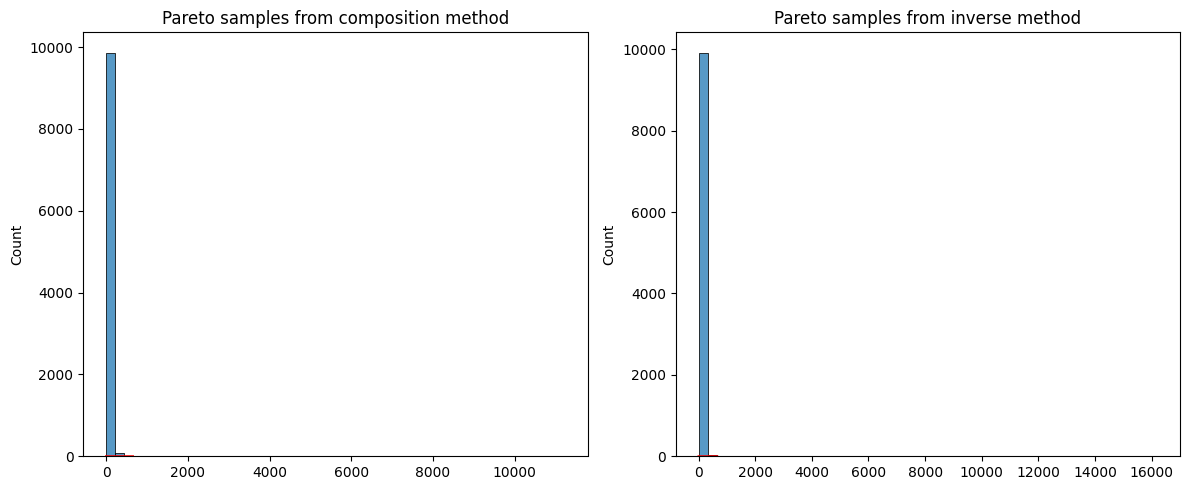

In [15]:
# Histograms of samples from pareto distribution using composite and inverse method
# Alongside their theoretical PDF
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

xs = np.linspace(0, max(samples), 100)
axes[0].plot(xs, scipy.stats.pareto.pdf(xs, 1, scale=2.5), color='red')
axes[1].plot(xs, scipy.stats.pareto.pdf(xs, 1, scale=2.5), color='red')

samples_composite = sample_pareto_composition(2.5)
samples_inverse = sample_pareto(1, 2.5)
seaborn.histplot(samples_composite, bins=50, ax=axes[0])
seaborn.histplot(samples_inverse, bins=50, ax=axes[1])
axes[0].set_title("Pareto samples from composition method")
axes[1].set_title("Pareto samples from inverse method")
fig.tight_layout()

KS test for Erlang samples: statistic=0.5955, p-value=0.0000


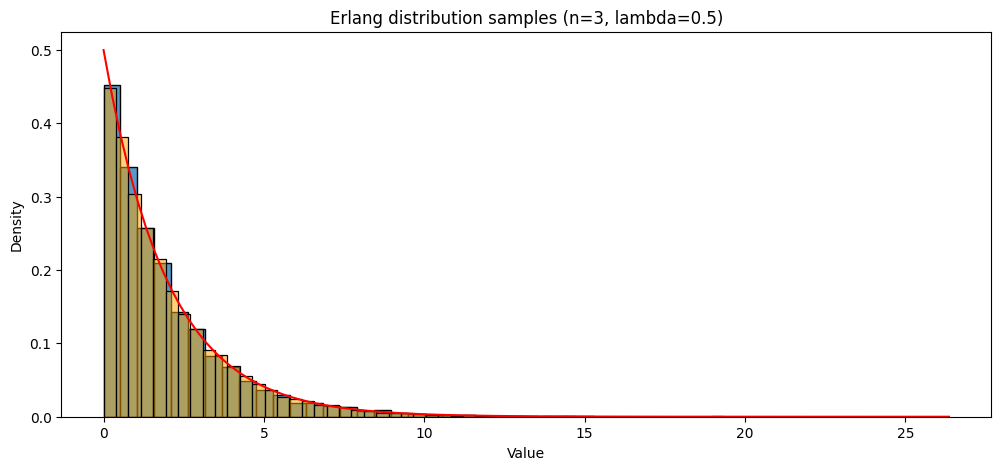

In [16]:
# Erlang distribution for n = 3, lambda = 0.5
# Plot histogram of samples and theoretical PDF
# Important because I need to sample it for exercise 4

# Also plot histogram of exponential distribution with lambda = 0.5 for comparison, since Erlang with n=1 is just exponential.

erlang_samples = sample_erlang(0.5, 1)
exp_samples = sample_exponential_dist(0.5)
x_erlang = np.linspace(0, max(erlang_samples), 100)

# KS test for Erlang samples
ks_erlang = scipy.stats.kstest(erlang_samples, 'gamma', args=(3, 0, 1/0.5))
print(f"KS test for Erlang samples: statistic={ks_erlang.statistic:.4f}, p-value={ks_erlang.pvalue:.4f}")

plt.figure(figsize=(12, 5))
seaborn.histplot(erlang_samples, bins=50, stat='density')
seaborn.histplot(exp_samples, bins=50, stat='density', color='orange', alpha=0.5)
plt.plot(x_erlang, scipy.stats.gamma.pdf(x_erlang, a=1, scale=1/0.5), color='red')
plt.title("Erlang distribution samples (n=3, lambda=0.5)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# Exercise 4

In [17]:
import heapq

NUM_CUSTOMERS = 100000      # Total number of simulated customers

In [18]:
M = 10                      # 10 service units
service_time = 8            # 8 time units
time_between_customers = 1  # 1 time unit

## STATES + INITIALIZATION
unit_busy = 0               # 0 means free, k>0 means k are busy.
T = 0                       # current time

## STATS
total_arrivals = 0
total_blocked  = 0

## EVENT TYPES
class EventType(StrEnum):
    ARRIVAL = "arrival"
    DEPARTURE = "departure"

## EVENT LIST
events: list[tuple[float, EventType]] = []

# pre-populate with a single arrival event at time 0
heapq.heappush(events, (0, EventType.ARRIVAL))

## MAIN SIMULATION LOOP
for _ in range(NUM_CUSTOMERS):
    t, event = heapq.heappop(events)

    match event:
        case EventType.ARRIVAL:
            # Schedule next arrival
            next_arrival_time = t + sample_exponential_dist(1/time_between_customers, num_samples=1)[0] 
            heapq.heappush(events, (next_arrival_time, EventType.ARRIVAL))

            total_arrivals += 1
            if unit_busy < M:
                unit_busy += 1
                departure_time = t + sample_exponential_dist(1/service_time, num_samples=1)[0] 
                heapq.heappush(events, (departure_time, EventType.DEPARTURE))
            else:
                total_blocked += 1
        case EventType.DEPARTURE:
            unit_busy -= 1

# Fraction of blocked customers
blocking_probability = total_blocked / total_arrivals
print(f"Total Arrivals: {total_arrivals}, Total Blocked: {total_blocked}, Blocking Probability: {blocking_probability:.4f}")
    
# Theoretical blocking probability
A = 8
theoretical_blocking_probability = (A ** M / math.factorial(M)) / sum([A ** i / math.factorial(i) for i in range(M + 1)])
print(f"Theoretical Blocking Probability: {theoretical_blocking_probability:.4f}")


Total Arrivals: 53213, Total Blocked: 6417, Blocking Probability: 0.1206
Theoretical Blocking Probability: 0.1217


In [19]:
### ERLANG DISTRIBUTED ARRIVALS

## STATES + INITIALIZATION
unit_busy = 0               # 0 means free, k>0 means k are busy.

## EVENT TYPES
class EventType(StrEnum):
    ARRIVAL = "arrival"
    DEPARTURE = "departure"

## EVENT LIST
events: list[tuple[float, EventType]] = []

# FOR CONFIDENCE INTERVALS
FRACTION_BLOCKED_SAMPLES_ERLANG = []
NUM_SIMULATIONS = 100

# Erlang stuff
n = 3

for _ in range(NUM_SIMULATIONS):
    ## STATS
    total_arrivals = 0
    total_blocked  = 0
    unit_busy = 0

    # pre-populate with a single arrival event at time 0
    heapq.heappush(events, (0, EventType.ARRIVAL))

    ## MAIN SIMULATION LOOP
    for _ in range(NUM_CUSTOMERS):
        t, event = heapq.heappop(events)

        match event:
            case EventType.ARRIVAL:
                # Schedule next arrival
                next_arrival_time = t + sample_erlang(n, n, num_samples=1)[0] 
                heapq.heappush(events, (next_arrival_time, EventType.ARRIVAL))

                total_arrivals += 1
                if unit_busy < M:
                    unit_busy += 1
                    departure_time = t + sample_exponential_dist(1/service_time, num_samples=1)[0] 
                    heapq.heappush(events, (departure_time, EventType.DEPARTURE))
                else:
                    total_blocked += 1
            case EventType.DEPARTURE:
                unit_busy -= 1

    # Fraction of blocked customers
    blocking_probability = total_blocked / total_arrivals
    FRACTION_BLOCKED_SAMPLES_ERLANG.append(blocking_probability)

In [20]:
### HYPEREXPONENTIALLY DISTRIBUTED ARRIVALS

## STATES + INITIALIZATION
unit_busy = 0               # 0 means free, k>0 means k are busy.

## EVENT TYPES
class EventType(StrEnum):
    ARRIVAL = "arrival"
    DEPARTURE = "departure"

## EVENT LIST
events: list[tuple[float, EventType]] = []

# FOR CONFIDENCE INTERVALS
FRACTION_BLOCKED_SAMPLES_HYPEREXPONENTIAL = []
NUM_SIMULATIONS = 100

# Hyperexponential stuff
ps = [0.8, 0.2]
lambdas = [0.8333, 5.0]

for _ in range(NUM_SIMULATIONS):
    ## STATS
    total_arrivals = 0
    total_blocked  = 0
    unit_busy = 0

    # pre-populate with a single arrival event at time 0
    heapq.heappush(events, (0, EventType.ARRIVAL))

    ## MAIN SIMULATION LOOP
    for _ in range(NUM_CUSTOMERS):
        t, event = heapq.heappop(events)

        match event:
            case EventType.ARRIVAL:
                # Schedule next arrival
                next_arrival_time = t + sample_hyperexponential(lambdas, ps, num_samples=1)[0] 
                heapq.heappush(events, (next_arrival_time, EventType.ARRIVAL))

                total_arrivals += 1
                if unit_busy < M:
                    unit_busy += 1
                    departure_time = t + sample_exponential_dist(1/service_time, num_samples=1)[0] 
                    heapq.heappush(events, (departure_time, EventType.DEPARTURE))
                else:
                    total_blocked += 1
            case EventType.DEPARTURE:
                unit_busy -= 1

    # Fraction of blocked customers
    blocking_probability = total_blocked / total_arrivals
    FRACTION_BLOCKED_SAMPLES_HYPEREXPONENTIAL.append(blocking_probability)

In [21]:
# Mean and variance of the fraction of blocked customers across simulations
mean_blocked = statistics.mean(FRACTION_BLOCKED_SAMPLES_ERLANG)
# CI for mean of blocked fraction
std_dev_blocked = statistics.stdev(FRACTION_BLOCKED_SAMPLES_ERLANG, mean_blocked)
confidence_interval = (mean_blocked - 1.96 * std_dev_blocked / math.sqrt(NUM_SIMULATIONS), mean_blocked + 1.96 * std_dev_blocked / math.sqrt(NUM_SIMULATIONS))
print(f"Mean Blocking Probability across simulations (erlang(3)): {mean_blocked:.4f}, 95% CI: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")    

mean_blocked = statistics.mean(FRACTION_BLOCKED_SAMPLES_HYPEREXPONENTIAL)
# CI for mean of blocked fraction
std_dev_blocked = statistics.stdev(FRACTION_BLOCKED_SAMPLES_HYPEREXPONENTIAL, mean_blocked)
confidence_interval = (mean_blocked - 1.96 * std_dev_blocked / math.sqrt(NUM_SIMULATIONS), mean_blocked + 1.96 * std_dev_blocked / math.sqrt(NUM_SIMULATIONS))
print(f"Mean Blocking Probability across simulations (hyperexponential): {mean_blocked:.4f}, 95% CI: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")

Mean Blocking Probability across simulations (erlang(3)): 0.0827, 95% CI: (0.0823, 0.0830)
Mean Blocking Probability across simulations (hyperexponential): 0.1381, 95% CI: (0.1375, 0.1387)


In [22]:
FRACTION_BLOCKED_LIST = []

In [23]:
# Part 3, different service time distributions
### Constant service time

## STATES + INITIALIZATION
unit_busy = 0

## EVENT TYPES
class EventType(StrEnum):
    ARRIVAL = "arrival"
    DEPARTURE = "departure"

## EVENT LIST
events: list[tuple[float, EventType]] = []

# FOR CONFIDENCE INTERVALS
FRACTION_BLOCKED_SAMPLES_PARETO_105_1 = []
NUM_SIMULATIONS = 100

FRACTION_BLOCKED_SAMPLES_CONSTANT = []

for _ in range(NUM_SIMULATIONS):
    ## STATS
    total_arrivals = 0
    total_blocked  = 0
    unit_busy = 0

    # pre-populate with a single arrival event at time 0
    heapq.heappush(events, (0, EventType.ARRIVAL))

    ## MAIN SIMULATION LOOP
    for _ in range(NUM_CUSTOMERS):
        t, event = heapq.heappop(events)

        match event:
            case EventType.ARRIVAL:
                # Schedule next arrival
                next_arrival_time = t + sample_exponential_dist(1/time_between_customers, num_samples=1)[0] 
                heapq.heappush(events, (next_arrival_time, EventType.ARRIVAL))

                total_arrivals += 1
                if unit_busy < M:
                    unit_busy += 1
                    departure_time = t + service_time  # constant service time
                    heapq.heappush(events, (departure_time, EventType.DEPARTURE))
                else:
                    total_blocked += 1
            case EventType.DEPARTURE:
                unit_busy -= 1

    # Fraction of blocked customers
    blocking_probability = total_blocked / total_arrivals
    FRACTION_BLOCKED_SAMPLES_CONSTANT.append(blocking_probability)

FRACTION_BLOCKED_LIST.append(("Constant", FRACTION_BLOCKED_SAMPLES_CONSTANT))

In [24]:
# Part 3, different service time distributions
### Pareto distributed (k = 1.05)

## STATES + INITIALIZATION
unit_busy = 0

## EVENT TYPES
class EventType(StrEnum):
    ARRIVAL = "arrival"
    DEPARTURE = "departure"

## EVENT LIST
events: list[tuple[float, EventType]] = []

# FOR CONFIDENCE INTERVALS
FRACTION_BLOCKED_SAMPLES_PARETO_105_1 = []
NUM_SIMULATIONS = 100

# Pareto distributed service times
k = 1.05
beta = 8*(k-1)/k  # set beta such that mean service time is 8, same as before

for _ in range(NUM_SIMULATIONS):
    ## STATS
    total_arrivals = 0
    total_blocked  = 0
    unit_busy = 0

    # pre-populate with a single arrival event at time 0
    heapq.heappush(events, (0, EventType.ARRIVAL))

    ## MAIN SIMULATION LOOP
    for _ in range(NUM_CUSTOMERS):
        t, event = heapq.heappop(events)

        match event:
            case EventType.ARRIVAL:
                # Schedule next arrival
                next_arrival_time = t + sample_exponential_dist(1/time_between_customers, num_samples=1)[0] 
                heapq.heappush(events, (next_arrival_time, EventType.ARRIVAL))

                total_arrivals += 1
                if unit_busy < M:
                    unit_busy += 1
                    departure_time = t + sample_pareto(k, beta, num_samples=1)[0]  # Pareto distributed service time
                    heapq.heappush(events, (departure_time, EventType.DEPARTURE))
                else:
                    total_blocked += 1
            case EventType.DEPARTURE:
                unit_busy -= 1

    # Fraction of blocked customers
    blocking_probability = total_blocked / total_arrivals
    FRACTION_BLOCKED_SAMPLES_PARETO_105_1.append(blocking_probability)

FRACTION_BLOCKED_LIST.append((f"Pareto (k={k}, beta={beta:.2f})", FRACTION_BLOCKED_SAMPLES_PARETO_105_1))

In [25]:
# Part 3, different service time distributions
### Pareto distributed (k = 2.05)

## STATES + INITIALIZATION
unit_busy = 0

## EVENT TYPES
class EventType(StrEnum):
    ARRIVAL = "arrival"
    DEPARTURE = "departure"

## EVENT LIST
events: list[tuple[float, EventType]] = []

# FOR CONFIDENCE INTERVALS
FRACTION_BLOCKED_SAMPLES_PARETO_205_1 = []
NUM_SIMULATIONS = 100

# Pareto distributed service times
k = 2.05
beta = 8*(k-1)/k  # set beta such that mean service time is 8, same as before

for _ in range(NUM_SIMULATIONS):
    ## STATS
    total_arrivals = 0
    total_blocked  = 0
    unit_busy = 0

    # pre-populate with a single arrival event at time 0
    heapq.heappush(events, (0, EventType.ARRIVAL))

    ## MAIN SIMULATION LOOP
    for _ in range(NUM_CUSTOMERS):
        t, event = heapq.heappop(events)

        match event:
            case EventType.ARRIVAL:
                # Schedule next arrival
                next_arrival_time = t + sample_exponential_dist(1/time_between_customers, num_samples=1)[0] 
                heapq.heappush(events, (next_arrival_time, EventType.ARRIVAL))

                total_arrivals += 1
                if unit_busy < M:
                    unit_busy += 1
                    departure_time = t + sample_pareto(k, beta, num_samples=1)[0]  # Pareto distributed service time
                    heapq.heappush(events, (departure_time, EventType.DEPARTURE))
                else:
                    total_blocked += 1
            case EventType.DEPARTURE:
                unit_busy -= 1

    # Fraction of blocked customers
    blocking_probability = total_blocked / total_arrivals
    FRACTION_BLOCKED_SAMPLES_PARETO_205_1.append(blocking_probability)

FRACTION_BLOCKED_LIST.append((f"Pareto (k={k}, beta={beta:.2f})", FRACTION_BLOCKED_SAMPLES_PARETO_205_1))

In [26]:
for dist_name, fraction_blocked in FRACTION_BLOCKED_LIST:
    mean_blocked = statistics.mean(fraction_blocked)
    # CI for mean of blocked fraction
    std_dev_blocked = statistics.stdev(fraction_blocked, mean_blocked)
    confidence_interval = (mean_blocked - 1.96 * std_dev_blocked / math.sqrt(NUM_SIMULATIONS), mean_blocked + 1.96 * std_dev_blocked / math.sqrt(NUM_SIMULATIONS))
    print(f"Mean Blocking Probability across simulations ({dist_name}): {mean_blocked:.4f}, 95% CI: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")

Mean Blocking Probability across simulations (Constant): 0.1218, 95% CI: (0.1215, 0.1222)
Mean Blocking Probability across simulations (Pareto (k=1.05, beta=0.38)): 0.0024, 95% CI: (0.0020, 0.0028)
Mean Blocking Probability across simulations (Pareto (k=2.05, beta=4.10)): 0.1215, 95% CI: (0.1210, 0.1221)


# Exercise 5

In [28]:
def get_ci(samples: list[float], confidence: float = 0.95) -> tuple[float, float]:
    """Assuming we can use the normal distribution, get the confidence interval for the mean of the samples."""
    mean = statistics.mean(samples)
    std_dev = statistics.stdev(samples, mean)
    z_score = scipy.stats.norm.ppf(1 - (1 - confidence) / 2)
    margin_of_error = z_score * std_dev / math.sqrt(len(samples))
    return (mean - margin_of_error, mean + margin_of_error)

True value of the integral: 1.7183
Estimated integral (monte carlo): 1.6193, 95% CI: (1.5253, 1.7133)
Estimated integral (antithetic): 1.7296, 95% CI: (1.6558, 1.8034)
Estimated integral (cont. variates): 1.7143, 95% CI: (1.7023, 1.7262)
Estimated integral (stratified): 1.7240, 95% CI: (1.7134, 1.7345)


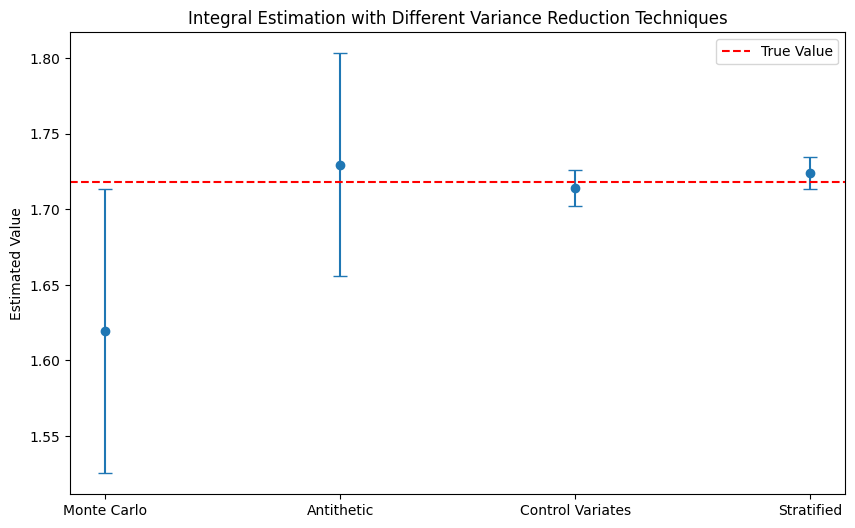

In [55]:
print(f"True value of the integral: {math.exp(1) - 1:.4f}")

# We need to estimate integral of e^x between 0 and 1; this we can do by sampling U ~ Uniform(0, 1) and then taking the mean of e^U with monte carlo sampling.
estimates = [math.exp(random.random()) for _ in range(100)]
confidence_interval = get_ci(estimates)
print(f"Estimated integral (monte carlo): {statistics.mean(estimates):.4f}, 95% CI: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")

# Using antithetic variates to reduce the variance.
estimates_antithetic = []
for _ in range(100):
    u = random.random()
    estimates_antithetic.append(math.exp(u))
    estimates_antithetic.append(math.exp(1 - u))

confidence_interval_antithetic = get_ci(estimates_antithetic)
print(f"Estimated integral (antithetic): {statistics.mean(estimates_antithetic):.4f}, 95% CI: ({confidence_interval_antithetic[0]:.4f}, {confidence_interval_antithetic[1]:.4f})")

# Using control variates with c = -1.69 and Z_i ~ U
control_variate_estimates = []
for _ in range(100):
    u = random.random()
    control_variate_estimates.append(math.exp(u) - 1.69 * (u - 0.5))

confidence_interval_control_variate = get_ci(control_variate_estimates)
print(f"Estimated integral (cont. variates): {statistics.mean(control_variate_estimates):.4f}, 95% CI: ({confidence_interval_control_variate[0]:.4f}, {confidence_interval_control_variate[1]:.4f})")

# Using stratified sampling with 10 strata.
stratified_estimates = []
for j in range(10):
    tmp_estimates = []
    num_strata = 10
    for i in range(num_strata):
        u = random.random() / num_strata + i / num_strata
        tmp_estimates.append(math.exp(u))
    stratified_estimates.append(statistics.mean(tmp_estimates))

confidence_interval_stratified = get_ci(stratified_estimates)
print(f"Estimated integral (stratified): {statistics.mean(stratified_estimates):.4f}, 95% CI: ({confidence_interval_stratified[0]:.4f}, {confidence_interval_stratified[1]:.4f})")

# Plot all 4 as point plot with error bars for the confidence intervals.
methods = ["Monte Carlo", "Antithetic", "Control Variates", "Stratified"]
estimates = [statistics.mean(estimates), statistics.mean(estimates_antithetic), statistics.mean(control_variate_estimates), statistics.mean(stratified_estimates)]
ci_lowers = [confidence_interval[0], confidence_interval_antithetic[0], confidence_interval_control_variate[0], confidence_interval_stratified[0]]
ci_uppers = [confidence_interval[1], confidence_interval_antithetic[1], confidence_interval_control_variate[1], confidence_interval_stratified[1]]
plt.figure(figsize=(10, 6))
plt.errorbar(methods, estimates, yerr=[np.array(estimates) - np.array(ci_lowers), np.array(ci_uppers) - np.array(estimates)], fmt='o', capsize=5)
plt.axhline(math.exp(1) - 1, color='red', linestyle='--', label='True Value')
plt.title("Integral Estimation with Different Variance Reduction Techniques")
plt.ylabel("Estimated Value")
plt.legend()
plt.show()

### Part 5 - Antithetic variables to reduce variance

As far as I understood, the way to go about this is to run a 'replica' simulation where the original uses the $U_i ~ U(0,1)$ for sampling the Poisson process, whereas the replica should use $1-U_i$. This negative correlatees the two instances, and we can find a blocking with $B_i = \frac{B_i^1 + B_i^2}{2}$ as the variable. It is possible to do this, because the variables are all monotone with regards to blocking. 

It does mean I need to alter my sampling algorith to allow dependence on $U_i$ and not be totally independent.

In [114]:
def sample_exponential(lamb: float, u: float) -> float:
    """New exponential sampler with pre-generated uniform random number u."""
    return -math.log(u) / lamb

# Constant
M = 10                      # 10 service units
service_time = 8            # 8 time units (mean of service distribution)
time_between_customers = 1  # 1 time unit (mean of arrival distribution)
NUM_CUSTOMERS = 10000

class EventType(StrEnum):
    ARRIVAL = "arrival"
    DEPARTURE = "departure"

def run_simulation(u_stream_arrivals: list[float], u_stream_services: list[float]):
    """I've rewritten the simulation to allow for 'deterministic' behavior in the sense that U_is are pre-generated."""
    unit_busy = 0
    total_arrivals = 0
    total_blocked = 0
    events: list[tuple[float, EventType]] = []
    heapq.heappush(events, (0.0, EventType.ARRIVAL))

    # Counters to track our position in the pre-generated random streams
    arrival_idx = 0
    service_idx = 0

    while total_arrivals < NUM_CUSTOMERS and events:
        t, event = heapq.heappop(events)

        match event:
            case EventType.ARRIVAL:
                total_arrivals += 1
                
                # 1. Schedule next arrival using the arrival stream
                if arrival_idx < len(u_stream_arrivals):
                    u_arr = u_stream_arrivals[arrival_idx]
                    arrival_idx += 1
                    next_arrival = t + sample_exponential(1 / time_between_customers, u_arr)
                    heapq.heappush(events, (next_arrival, EventType.ARRIVAL))

                # 2. Handle current customer service
                if unit_busy < M:
                    unit_busy += 1
                    # Use the service stream only when a customer is actually served
                    if service_idx < len(u_stream_services):
                        u_ser = u_stream_services[service_idx]
                        service_idx += 1
                        departure_time = t + sample_exponential(1 / service_time, u_ser)
                        heapq.heappush(events, (departure_time, EventType.DEPARTURE))
                else:
                    total_blocked += 1

            case EventType.DEPARTURE:
                unit_busy -= 1

    return total_blocked / total_arrivals

# random.seed(42) # For reproducibility

# Pre-generate the master uniform random streams for the original run
u_arrivals_orig = [random.random() for _ in range(NUM_CUSTOMERS)]
u_services_orig = [random.random() for _ in range(NUM_CUSTOMERS)]

# Create the antithetic streams (1 - U)
u_arrivals_anti = [1.0 - u for u in u_arrivals_orig]
u_services_anti = [1.0 - u for u in u_services_orig]

# Run both simulations
p_original = run_simulation(u_arrivals_orig, u_services_orig)
p_antithetic = run_simulation(u_arrivals_anti, u_services_anti)

# Combine the results
p_balanced = (p_original + p_antithetic) / 2

print(f"Original Stream Blocking Prob:   {p_original:.4f}")
print(f"Antithetic Stream Blocking Prob: {p_antithetic:.4f}")
print(f"Antithetic Balanced Estimate:    {p_balanced:.4f}")

# Theoretical comparison (Erlang-B)
A = service_time / time_between_customers
theoretical = (A**M / math.factorial(M)) / sum([A**i / math.factorial(i) for i in range(M + 1)])
print(f"Theoretical Blocking Prob:       {theoretical:.4f}")

Original Stream Blocking Prob:   0.1247
Antithetic Stream Blocking Prob: 0.1225
Antithetic Balanced Estimate:    0.1236
Theoretical Blocking Prob:       0.1217


In [115]:
import numpy as np

# --- Variance Comparison Experiment ---
NUM_REPLICATIONS = 50  # Number of pairs to run

estimates_independent = []
estimates_antithetic = []

for _ in range(NUM_REPLICATIONS):
    # 1. Generate independent streams for the original run
    u_arr_orig = [random.random() for _ in range(NUM_CUSTOMERS)]
    u_ser_orig = [random.random() for _ in range(NUM_CUSTOMERS)]
    
    # 2. Generate completely independent streams for a second standard run
    u_arr_indep = [random.random() for _ in range(NUM_CUSTOMERS)]
    u_ser_indep = [random.random() for _ in range(NUM_CUSTOMERS)]
    
    # 3. Create the antithetic streams from the original
    u_arr_anti = [1.0 - u for u in u_arr_orig]
    u_ser_anti = [1.0 - u for u in u_ser_orig]
    
    # Run all variants
    p_orig = run_simulation(u_arr_orig, u_ser_orig)
    p_indep = run_simulation(u_arr_indep, u_ser_indep)
    p_anti = run_simulation(u_arr_anti, u_ser_anti)
    
    # Scenario A: Average of two completely independent runs (Same sample size/effort as antithetic)
    p_combined_independent = (p_orig + p_indep) / 2
    estimates_independent.append(p_combined_independent)
    
    # Scenario B: Average of the antithetic pair
    p_combined_antithetic = (p_orig + p_anti) / 2
    estimates_antithetic.append(p_combined_antithetic)

# --- Calculate Variances ---
var_independent = np.var(estimates_independent, ddof=1)
var_antithetic = np.var(estimates_antithetic, ddof=1)
variance_reduction = (var_independent - var_antithetic) / var_independent * 100

print("--- Variance Analysis ---")
print(f"Variance (Independent Pairs): {var_independent:.8f}")
print(f"Variance (Antithetic Pairs):  {var_antithetic:.8f}")
print(f"Variance Reduction:           {variance_reduction:.2f}%")

--- Variance Analysis ---
Variance (Independent Pairs): 0.00001976
Variance (Antithetic Pairs):  0.00001003
Variance Reduction:           49.26%


In [116]:
# part 7 - Z ~ N(0,1), Estimate P(Z > a) using Crude MC.
# Then we try with importance sampling using a normal distribution with mean a and some variance sigma^2.

# True values (P(Z > 2) and P(Z > 4))
true_p_2 = 1 - scipy.stats.norm.cdf(2)
true_p_4 = 1 - scipy.stats.norm.cdf(4)
print(f"True P(Z > 2): {true_p_2:.6f}, True P(Z > 4): {true_p_4:.6f}")

n_pdf = lambda x, mu, sigma: (1 / (sigma * math.sqrt(2 * math.pi))) * math.exp(-0.5 * ((x - mu) / sigma) ** 2)

sigma_sq = 1

# Monte Carlo
for a_ in [2, 4]:
    Z = sample_standard_normal_box_mueller(num_samples=NUM_SAMPLES)
    ci_Z = get_ci([(z > a_) for z in Z])
    print(f"Estimated P(Z > {a_}) with crude MC: {statistics.mean([(z > a_) for z in Z]):.6f}, 95% CI: ({ci_Z[0]:.6f}, {ci_Z[1]:.6f})")

# Importance Sampling from g ~ N(a, sigma^2)
for a_ in [2, 4]:
    Z_ = sample_standard_normal_box_mueller(num_samples=NUM_SAMPLES)
    G = [a_ + math.sqrt(sigma_sq) * z_ for z_ in Z_]  # linear transform from standard normal
    weights = [n_pdf(g, 0, 1) / n_pdf(g, a_, math.sqrt(sigma_sq)) for g in G]  # w(x) = f(x) / g(x)
    ci_IS = get_ci([w if g > a_ else 0 for g, w in zip(G, weights)])
    print(f"Estimated P(Z > {a_}) with importance sampling: {statistics.mean([w if g > a_ else 0 for g, w in zip(G, weights)]):.6f}, 95% CI: ({ci_IS[0]:.6f}, {ci_IS[1]:.6f})")


True P(Z > 2): 0.022750, True P(Z > 4): 0.000032
Estimated P(Z > 2) with crude MC: 0.024800, 95% CI: (0.021752, 0.027848)
Estimated P(Z > 4) with crude MC: 0.000000, 95% CI: (0.000000, 0.000000)
Estimated P(Z > 2) with importance sampling: 0.022257, 95% CI: (0.021582, 0.022933)
Estimated P(Z > 4) with importance sampling: 0.000032, 95% CI: (0.000031, 0.000033)


In [98]:
# Similar tests to above, but with different values of sigma, to see how it affects the variance of the estimator.
for a_ in [2, 4]:
    for sigma_sq in [0.5, 1, 2, 5]:
        Z_ = sample_standard_normal_box_mueller(num_samples=NUM_SAMPLES)
        G = [a_ + math.sqrt(sigma_sq) * z_ for z_ in Z_]  # linear transform from standard normal
        weights = [n_pdf(g, 0, 1) / n_pdf(g, a_, math.sqrt(sigma_sq)) for g in G]  # w(x) = f(x) / g(x)
        ci_IS = get_ci([w if g > a_ else 0 for g, w in zip(G, weights)])
        print(f"Estimated P(Z > {a_}) with importance sampling (sigma^2={sigma_sq}): {statistics.mean([w if g > a_ else 0 for g, w in zip(G, weights)]):.6f}, 95% CI: ({ci_IS[0]:.6f}, {ci_IS[1]:.6f})")

Estimated P(Z > 2) with importance sampling (sigma^2=0.5): 0.022159, 95% CI: (0.021622, 0.022697)
Estimated P(Z > 2) with importance sampling (sigma^2=1): 0.022941, 95% CI: (0.022255, 0.023627)
Estimated P(Z > 2) with importance sampling (sigma^2=2): 0.022915, 95% CI: (0.022059, 0.023772)
Estimated P(Z > 2) with importance sampling (sigma^2=5): 0.023270, 95% CI: (0.022139, 0.024400)
Estimated P(Z > 4) with importance sampling (sigma^2=0.5): 0.000031, 95% CI: (0.000030, 0.000032)
Estimated P(Z > 4) with importance sampling (sigma^2=1): 0.000031, 95% CI: (0.000030, 0.000032)
Estimated P(Z > 4) with importance sampling (sigma^2=2): 0.000031, 95% CI: (0.000030, 0.000033)
Estimated P(Z > 4) with importance sampling (sigma^2=5): 0.000031, 95% CI: (0.000029, 0.000033)


### Exercise part 8
In this part we are again back to evaluating the interal of $\int_0^1 \exp(x) dx$. This time, however, we utilize importance sampling with
$$ g(x) = \lambda\exp(-\lambda x) $$

As the variance is of $$ \frac{h(X)f(X)}{g(X)}, $$
where $h(X) = \exp(X)$ and $f(X)=1$ due to Uniform distribution.

We need the variance of $Y = h(X)f(X)/g(X)$, so it will be $E[Y^2] - E[Y]^2$. By definition, $E[Y] = e - 1$, so $E[Y]^2 = (e-1)^2$. Likewise, we need to find $E[Y^2]$:
$$ \begin{align*}
E[Y^2] &= \int_0^1 \left(\frac{e^x \cdot 1}{\lambda e^{-\lambda x}}\right)^2 \cdot \lambda e^{-\lambda x} dx \\
&= \int_0^1 \frac{e^{2x}}{\lambda^2e^{-2\lambda x}} \cdot \lambda e^{-\lambda x} dx \\
&= \int_0^1 \frac{e^{2x}}{\lambda e^{-\lambda x}} dx \\
&= \frac{1}{\lambda}\int_0^1 \frac{e^{2x}}{e^{-\lambda x}} dx \\
&= \frac{1}{\lambda}\int_0^1 e^{2x}e^{\lambda x} dx = \frac{1}{\lambda}\int_0^1 e^{(2+\lambda)x} dx
\end{align*} $$

Evaluating above integral in its range evaluates to $$ \frac{e^{2+\lambda}-1}{\lambda(2+\lambda)} $$ And the full variance is then found to be $$ \mathbb{V}[Y] = \frac{e^{2+\lambda}-1}{\lambda(2+\lambda)} - (e - 1)^2. $$ We want to minimize this variance by tuning only $\lambda$. Solving for $\lambda$ and minimizing numerically gave a result of $\lambda \approx 1.35$.

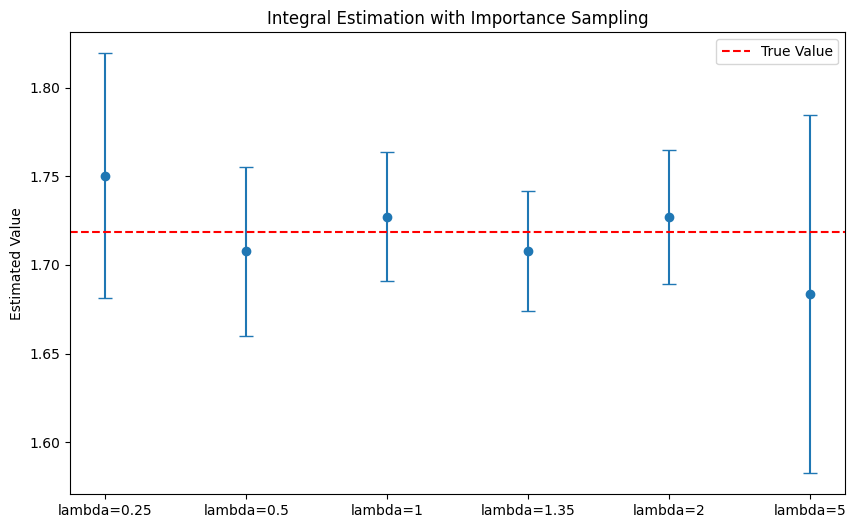

In [112]:
# Let us simulate different values and verify. Optimal lambda around 1.35
g_pdf = lambda x, lamb: lamb * math.exp(-lamb * x) if x >= 0 else 0

lambda_values = [0.25, 0.5, 1, 1.35, 2, 5]
method_labels = [f"lambda={lambda_}" for lambda_ in lambda_values]
estimate_values = []
ci_lowers = []
ci_uppers = []

for lambda_ in lambda_values:
    X = sample_exponential_dist(lambda_, num_samples=NUM_SAMPLES)
    estimates = [math.exp(x) / g_pdf(x, lambda_) if 0 <= x <= 1 else 0 for x in X]
    ci_IS = get_ci(estimates)
    estimate_values.append(statistics.mean(estimates))
    ci_lowers.append(ci_IS[0])
    ci_uppers.append(ci_IS[1])

plt.figure(figsize=(10, 6))
plt.errorbar(
    method_labels,
    estimate_values,
    yerr=[np.array(estimate_values) - np.array(ci_lowers), np.array(ci_uppers) - np.array(estimate_values)],
    fmt='o',
    capsize=5,
)
plt.axhline(math.exp(1) - 1, color='red', linestyle='--', label='True Value')
plt.title("Integral Estimation with Importance Sampling")
plt.ylabel("Estimated Value")
plt.legend()
plt.show()